# Non-Hermitian 1D Chain With Loss

This notebook shows the basic workflow for the non-Hermitian tools in `NH_tk.jl`:

1. Build a 1D tight-binding Hamiltonian and add a loss term.
2. Pick one complex energy point `z`.
3. Hermitize `zI - H` with the extra non-Hermitian block.
4. Run the NH KPM recursion and read out a site-resolved LDOS-like profile.

In [1]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl") # if you have the package installed, you can directly do using TensorBinding
using .TensorBinding

## 1. Build a lossy chain

Start from a nearest-neighbour 1D chain and add an imaginary diagonal loss term. The real loss profile `f(n)` is defined on the full Hamiltonian basis coordinate `n`, compressed into a diagonal MPO by QTCI, and only then multiplied by the factor `-im`.

In [3]:
L = 3              # N = 2^L sites
t = 1.0
λ = 0.8

H = TensorBinding.get_Hamiltonian("chain_1d", t; L=L)
 
loss_profile(n) = λ #constant loss

# Builds diag(loss_profile) first, then adds im * diag(loss_profile) to H.mpo.
TensorBinding.add_loss!(H, loss_profile; coefficient=1im, maxdim=80)

println(H)

TBHamiltonian | L=3, N=8, scale=auto, maxlinkdim=3 | geometry: 8 sites, 1D | no Tn cache


## 2. Choose one complex energy

For this minimal example we evaluate only one point in the complex plane. `scale` is the Chebyshev normalization for the hermitized operator; choose it larger than the singular-value bandwidth of `zI - H`.

In [4]:
z = 0.0 + 0.15im
scale = 4.0
Ncheb_half = 20       # NH recursion uses 2*Ncheb_half partial moments
maxdim = 100

println("z = ", z, ", scale = ", scale)

z = 0.0 + 0.15im, scale = 4.0


## 3. Hermitize at this energy

The old NH workflow used `zI - H`, so the example uses `convention=:z_minus_H`.

In [5]:
NH = TensorBinding.hermitize(H; z=z, scale=scale, maxdim=maxdim,
                            convention=:z_minus_H)

println(NH)
println(NH.hermitized)

NonHermitianHamiltonian | z=0.0 + 0.15im, blockdim=2, hermitized maxlinkdim=3
TBHamiltonian | L=3, N=8, scale=4.0, maxlinkdim=3 | geometry: 8 sites, 1D | no Tn cache


0.6499999999999999
-0.6499999999999996


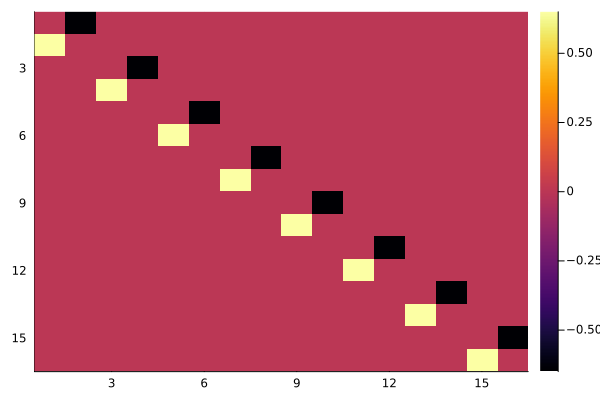

In [6]:
#check the proper hermitrized Hamiltonian
hermitized_mpo = NH.hermitized
M = TensorBinding.get_matrix(hermitized_mpo.mpo, hermitized_mpo.sites)
println(maximum(imag.(M)))
println(minimum(imag.(M)))
heatmap(imag.(M),yflip=true)

## 4. NH KPM and LDOS

`nh_spectral_function` returns a diagonal MPS `A_mps`. Evaluating that MPS at each site gives a real-space LDOS-like profile for the chosen complex energy.

In [7]:
A_mps, dos_point, partials = TensorBinding.nh_spectral_function(
    NH, Ncheb_half;
    scale=scale,
    maxdim=maxdim,
    cutoff=1e-8,
)

ldos = [TensorBinding._eval_diag_mps(A_mps, x) for x in 0:H.N-1]

println("total spectral weight at z = ", dos_point)
println("computed ", length(partials), " partial moments")

┌ Warning: Calling `inner(x::MPS, A::MPO, y::MPS)` where the site indices of the `MPS`
│ `x` and the `MPS` resulting from contracting `MPO` `A` with `MPS` `y` don't
│ match is deprecated as of ITensors v0.3 and will result in an error in ITensors
│ v0.4. The most common cause of this is something like the following:
│ 
│ ```julia
│ s = siteinds("S=1/2")
│ psi = random_mps(s)
│ H = MPO(s, "Id")
│ inner(psi, H, psi)
│ ```
│ 
│ `psi` has the Index structure `-s-(psi)` and `H` has the Index structure
│ `-s'-(H)-s-`, so the Index structure of would be `(dag(psi)-s- -s'-(H)-s-(psi)`
│  unless the prime levels were fixed. Previously we tried fixing the prime level
│   in situations like this, but we will no longer be doing that going forward.
│ 
│ There are a few ways to fix this. You can simply change:
│ 
│ ```julia
│ inner(psi, H, psi)
│ ```
│ 
│ to:
│ 
│ ```julia
│ inner(psi', H, psi)
│ ```
│ 
│ in which case the Index structure will be `(dag(psi)-s'-(H)-s-(psi)`.
│ 
│ Alternatively, you c

total spectral weight at z = -2.3094390071048916 - 6.9615341257962275e-15im
computed 40 partial moments


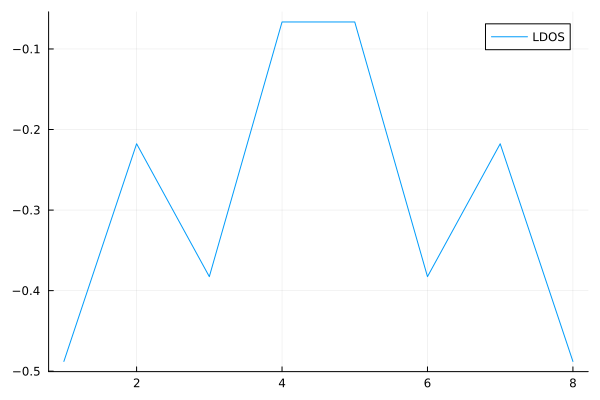

In [8]:
plot(ldos, label="LDOS")